In [298]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [299]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural_pilot', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [300]:
# Preparation
experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')
#experiment_output_path = os.path.join('..', '..', '..', 'phd_1_task', 'experiment_output_verena')

In [301]:
unique_subject_ids = list(range(901, 916))
unique_sessions = [1]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)

In [302]:
print(recent_results)

['../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-901_session-01_dummy_2024-06-26_11-18-46.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-902_session-01_dummy_2024-06-26_13-40-01.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-903_session-01_dummy_2024-06-26_15-40-24.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-904_session-01_dummy_2024-06-27_09-44-36.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-905_session-01_dummy_2024-06-27_11-10-43.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-906_session-01_dummy_2024-06-27_13-39-31.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-907_session-01_dummy_2024-06-27_15-07-37.csv', '../../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-908_session-01_dummy_2024-06-2

In [303]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if 'verena' in experiment_output_path:
    combined_results_dataframe = combined_results_dataframe[~combined_results_dataframe['stimuli_type'].isin([2, 4])]

print(combined_results_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          0        1.719394e+09      NaN                Late   
1          1        1.719394e+09       up                Even   
2          2        1.719394e+09       up                Even   
3          3        1.719394e+09     down                Even   
4          4        1.719394e+09     down                Even   
...      ...                 ...      ...                 ...   
10195    675        1.720007e+09       up                True   
10196    676        1.720007e+09     down                True   
10197    677        1.720007e+09       up                True   
10198    678        1.720007e+09     down                True   
10199    679        1.720007e+09       up                True   

      subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                     Late   1.719394e+09  1.202             1    3   
1                     True   1.719394e+09  1.201             3    2   
2     

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [304]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [305]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

       stimuli_type  probability_condition congruency
0                 1                     50  undefined
1                 3                     50  undefined
2                 3                     50  undefined
3                 1                     50  undefined
4                 1                     50  undefined
...             ...                    ...        ...
10195             1                     80  congruent
10196             3                     20  congruent
10197             1                     80  congruent
10198             3                     20  congruent
10199             1                     80  congruent

[10200 rows x 3 columns]


In [306]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

# Statistics
Start by checking if the objectively correct answers significantly differ from chance

In [307]:
# Filter out trials with 50% reward probability and without responses
stats_dataframe = combined_results_dataframe.drop(combined_results_dataframe[(combined_results_dataframe.probability_condition == 50) | (combined_results_dataframe.objectively_correct == 'Late')].index, inplace=False)
# Calculate the total number of successes and the total number of trials
total_successes = stats_dataframe['objectively_correct_boolean'].sum()
total_trials = len(stats_dataframe)

# Calculate expected successes and failures if each trial has a 50% chance of success
expected_successes = total_trials * 0.5
expected_failures = total_trials * 0.5

# Perform the chi-square goodness of fit test
chi2_stat, p_value = chisquare([total_successes, total_trials - total_successes],
                               f_exp=[expected_successes, expected_failures])

print(chi2_stat, p_value)

1020.2308005289391 7.192216183694941e-224


In [308]:
# Multiply the boolean response by 100 to get percentages, can only do this after the stats
combined_results_dataframe['objectively_correct_boolean'] *= 100

# Objectively correct answer binned after every switch

In [309]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0

objectively_correct_answers_per_switch_block = pd.DataFrame()

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]
        
        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        
        # Filter out trials with 50% reward probability and without responses
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.drop(combined_results_grouped_dataframe[(combined_results_grouped_dataframe.probability_condition == 50) | (combined_results_grouped_dataframe.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.reset_index()
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()
        print(f'{index_stimuli}, {index_subject_id}, {switches_reward}')
        
        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = dataframe_containing_groups_filtered.iloc[values:values+11]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 10: 8, 11: 9, 12: 10, 13: 11, 14: 12})

1, sub-901, [0, 26, 57, 65, 77, 87, 99, 130, 158, 170, 180, 194, 206, 237, 265, 279, 289, 301, 315]
1, sub-902, [0, 10, 22, 32, 44, 76, 104, 118, 128, 142, 154, 186, 214, 228, 238, 250, 264, 296, 324]
1, sub-903, [0, 13, 22, 43, 68, 111, 125, 135, 146, 174, 205, 218, 228, 240, 254, 281, 313]
1, sub-904, [29, 53, 64, 74, 85, 94, 119, 147, 155, 165, 179, 191, 217, 248, 262, 272, 283, 297]
1, sub-905, [0, 28, 60, 70, 90, 102, 134, 161, 175, 185, 198, 209, 241, 282, 291, 302, 315]
1, sub-906, [0, 32, 60, 74, 84, 96, 108, 136, 168, 178, 188, 202, 214, 242, 272, 285, 295, 307, 321]
1, sub-907, [0, 31, 59, 71, 80, 91, 123, 154, 164, 173, 186, 198, 222, 252, 265, 275, 287, 301]
1, sub-908, [0, 14, 24, 34, 45, 72, 103, 115, 129, 139, 151, 178, 210, 224, 234, 246, 260, 288, 320]
1, sub-909, [0, 27, 56, 64, 76, 86, 98, 130, 157, 170, 180, 194, 237, 264, 278, 288, 299, 313]
1, sub-910, [0, 10, 22, 32, 44, 76, 104, 118, 128, 142, 154, 186, 214, 237, 249, 263, 292, 317]
1, sub-911, [13, 23, 33, 44, 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3577/265265751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3577/265265751.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld

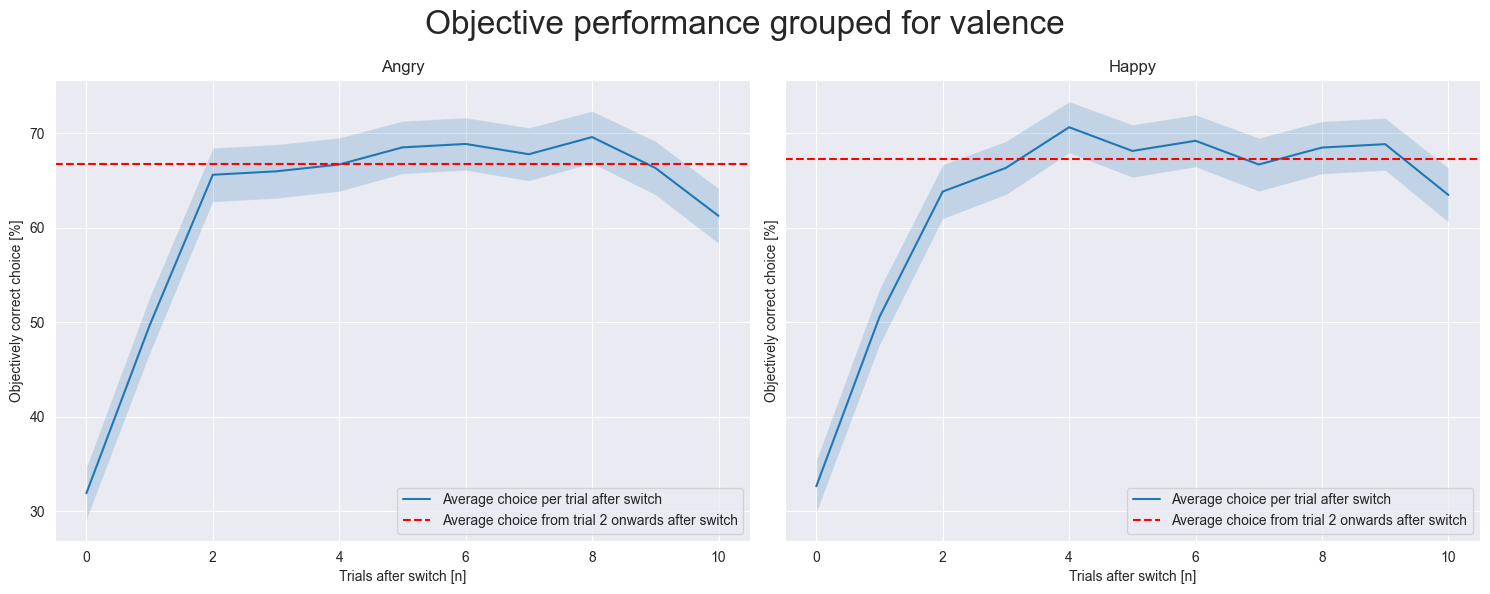

In [310]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = np.arange(len(means.columns))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_0-12.pdf'))
plt.show()

# Now the same but split for congruency and valence

In [311]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids,
                                                                             unique_stimuli_types,
                                                                             'congruency',
                                                                             plot_range,
                                                                             mapping)
print(all_switches_dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

    subject_id  stimuli_type   congruency    0    1    2    3    4    5    6  \
0      sub-901             1    congruent    0    0    0  100    0    0    0   
1      sub-901             1    congruent    0    0  100    0    0    0    0   
2      sub-901             1    congruent  100    0    0    0    0  100  100   
3      sub-901             1    congruent  100    0  100  100    0  100    0   
4      sub-901             1    congruent    0    0  100  100  100  100  100   
..         ...           ...          ...  ...  ...  ...  ...  ...  ...  ...   
550    sub-915             3  incongruent    0    0  100  100  100  100    0   
551    sub-915             3  incongruent  100  100  100  100  100  100  100   
552    sub-915             3  incongruent    0    0  100  100  100  100  100   
553    sub-915             3  incongruent    0  100  100  100  100  100  100   
554    sub-915             3  incongruent    0  100  100  100  100  100    0   

       7    8    9   10  
0      0    0

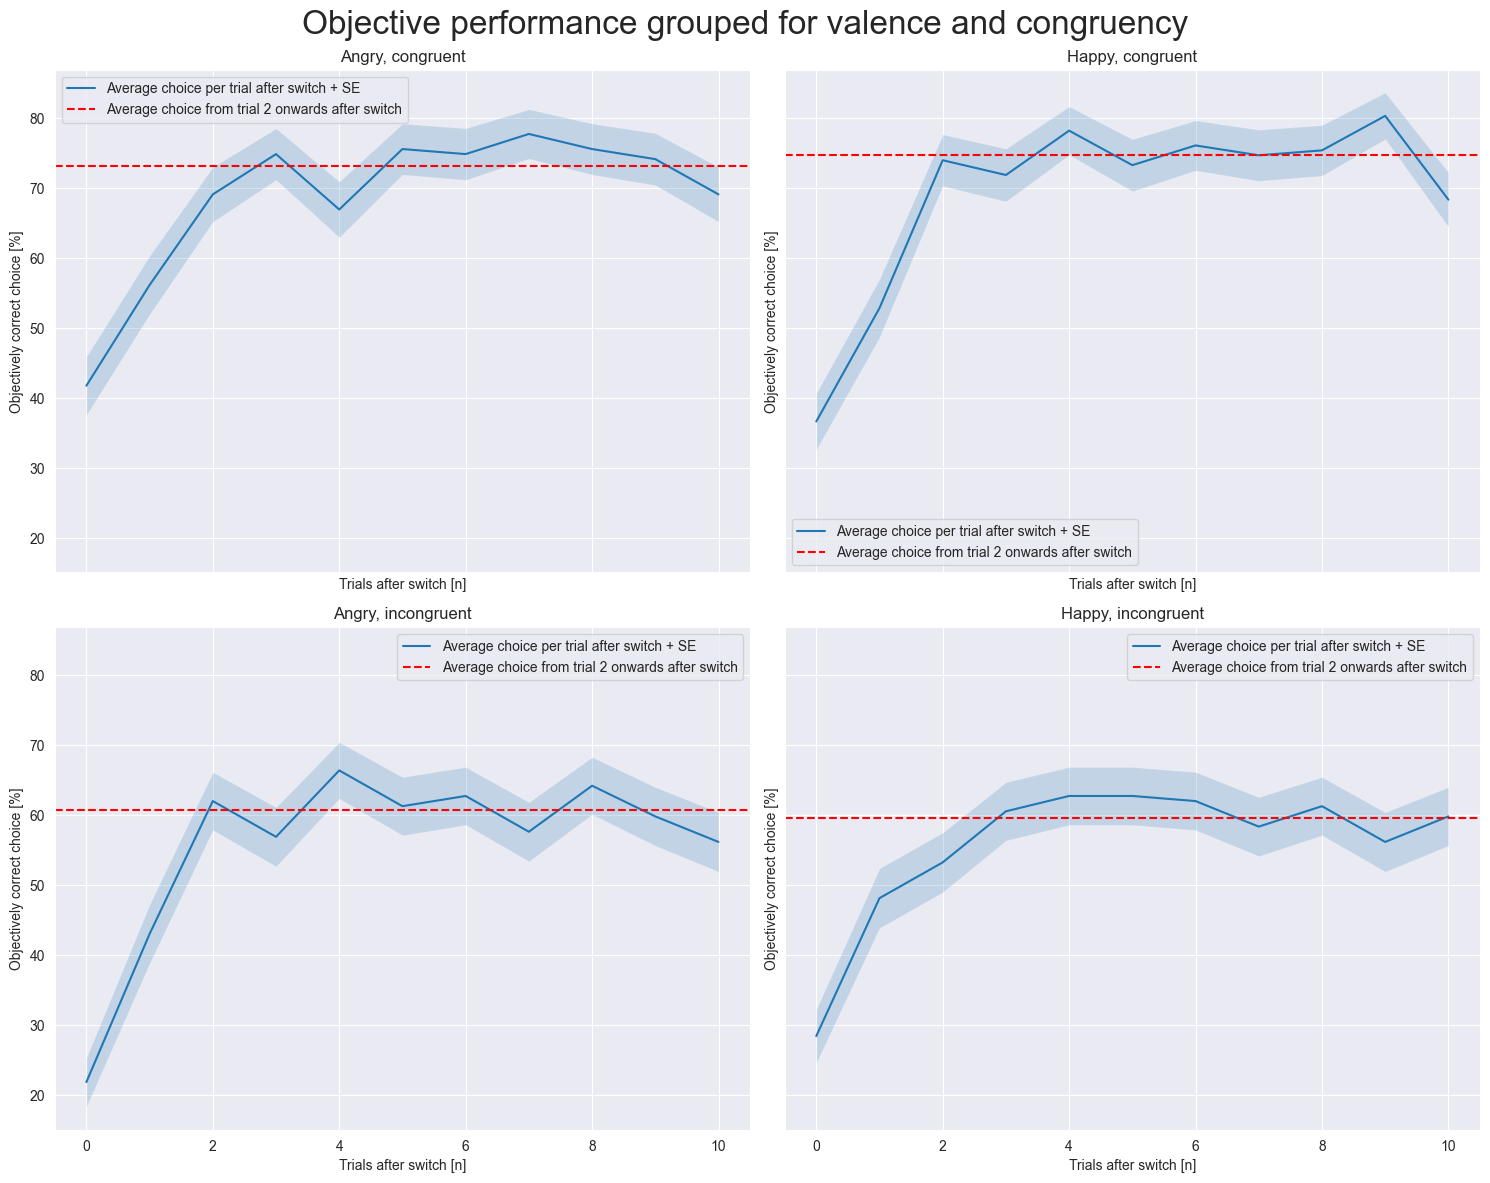

In [312]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

## objectively correct answers without binning
Now we'll look at the objectively correct answers in a sequential manner, so without binning them based on switches in reward contingencies.
Plot probability of correct response on Y-axis to trials on X-axis

In [313]:
# Take the mean from all 12 trials after each switch
trials_after_switch_to_plot = list(range(0,11))
intermediate_dataframe = objectively_correct_answers_per_switch_block
intermediate_dataframe['switch_number'] = intermediate_dataframe.groupby(['subject_id','stimuli_type']).cumcount()
print(intermediate_dataframe)

# Preparation for loop
unique_switches = intermediate_dataframe['switch_number'].unique()
column_names = ['stimuli_type', 'switch'] + trials_after_switch_to_plot
objectively_correct_answers_averaged_per_switch_block = pd.DataFrame(columns = column_names)

# Loop through each stimulus and switch type
for index_stimuli, value_stimuli in enumerate(unique_stimuli_types):
    for index_switch, value_switch in enumerate(unique_switches):
        filtered_dataframe = intermediate_dataframe[(intermediate_dataframe['stimuli_type'] == value_stimuli) & (intermediate_dataframe['switch_number'] == value_switch)]
        list_with_averages = [value_stimuli, value_switch] + (filtered_dataframe[trials_after_switch_to_plot].mean()).to_list()
        objectively_correct_answers_averaged_per_switch_block.loc[len(objectively_correct_answers_averaged_per_switch_block)] = list_with_averages

    subject_id  stimuli_type    0    1    2    3    4    5    6    7    8  \
0      sub-901             1    0    0    0  100    0    0    0    0    0   
1      sub-901             1  100    0    0  100  100  100  100    0    0   
2      sub-901             1    0    0  100    0    0    0    0  100    0   
3      sub-901             1    0    0  100    0  100  100  100  100  100   
4      sub-901             1  100    0    0    0    0  100  100    0  100   
..         ...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
550    sub-915             3    0  100  100  100  100  100  100  100  100   
551    sub-915             3    0  100  100  100  100  100  100  100  100   
552    sub-915             3    0    0  100  100  100  100  100  100    0   
553    sub-915             3    0  100  100  100  100  100    0  100    0   
554    sub-915             3    0    0    0  100  100    0    0    0  100   

       9   10  switch_number  
0    100  100              0  
1    100    0

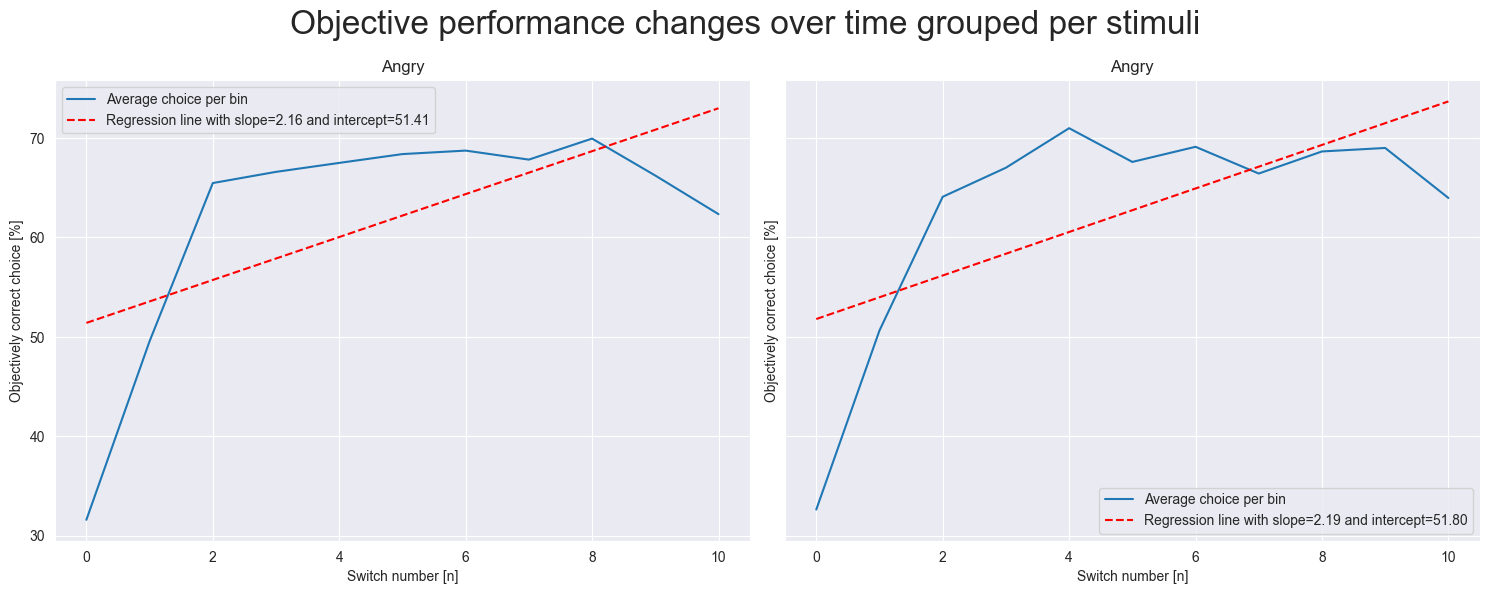

In [314]:
# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance changes over time grouped per stimuli', fontsize=24, y=0.982)

for index_stimuli, value_stimuli in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    filtered_dataframe = objectively_correct_answers_averaged_per_switch_block[objectively_correct_answers_averaged_per_switch_block['stimuli_type'] == value_stimuli]
    filtered_dataframe = filtered_dataframe.drop(['stimuli_type', 'switch'], axis=1)

    timepoints = [int(col) for col in filtered_dataframe.columns]
    averages = filtered_dataframe.mean()
    a, b = np.polyfit(timepoints, averages, 1)
    regression_line = [i * a + b for i in timepoints]

    axs[index_stimuli].plot(averages, label='Average choice per bin')
    axs[index_stimuli].plot(timepoints, regression_line, color='r', linestyle='--', label=f'Regression line with slope={a:.2f} and intercept={b:.2f}')
    axs[index_stimuli].set_title(stimuli_types_list[index_stimuli])
    axs[index_stimuli].set_xlabel('Switch number [n]')
    axs[index_stimuli].set_ylabel('Objectively correct choice [%]')
    axs[index_stimuli].legend()
    axs[index_stimuli].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_changes_over_time_grouped_per_stimuli.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [315]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-10, 5))

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-10:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -10, 3: -9, 4: -8, 5: -7, 6: -6, 7: -5, 8: -4, 9: -3, 10: -2, 11: -1, 12: 0, 13: 1, 14: 2, 15: 3, 16: 4})

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3577/3708134271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3577/3708134271.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/

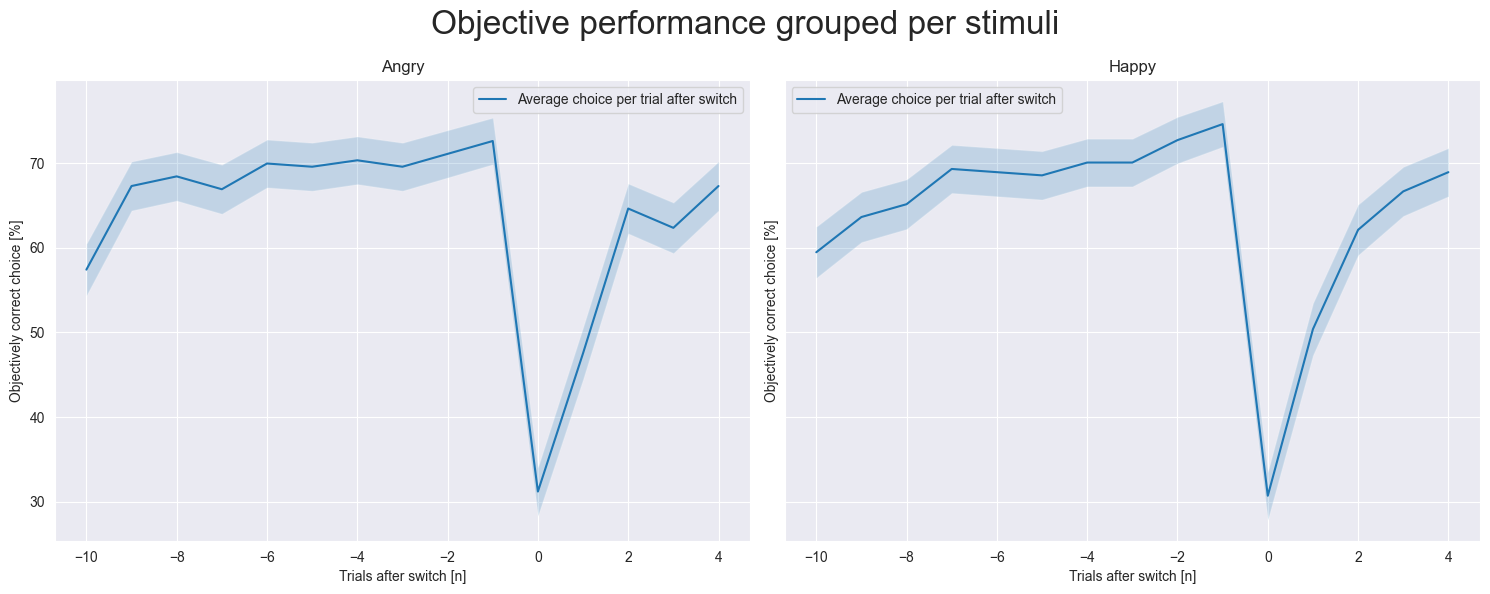

In [316]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    #axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_12-4.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 4 trials before the switch and ending 12 after.

In [317]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-4, 11))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: -4, 3: -3, 4: -2, 5: -1, 6: 0, 7: 1, 8: 2, 9: 3, 10: 4, 11: 5, 12: 6, 13: 7, 14: 8, 15: 9, 16: 10}

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values+min(plot_range):values+max(plot_range)+1]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns=mapping)
print(objectively_correct_answers_per_switch_block)

    subject_id  stimuli_type   -4   -3   -2   -1    0    1    2    3    4  \
0      sub-901             1    0    0    0    0    0    0    0  100    0   
1      sub-901             1    0    0    0  100  100    0    0  100  100   
2      sub-901             1    0  100    0  100    0    0    0  100    0   
3      sub-901             1    0    0    0  100    0    0  100    0  100   
4      sub-901             1  100  100    0  100  100    0    0    0    0   
..         ...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
550    sub-915             3  100  100  100  100    0  100  100  100  100   
551    sub-915             3  100  100  100  100    0  100  100  100  100   
552    sub-915             3  100  100  100    0    0    0  100  100  100   
553    sub-915             3    0  100  100  100    0  100  100  100  100   
554    sub-915             3  100  100  100  100    0    0    0  100  100   

       5    6    7    8    9   10  
0      0    0    0    0    0    0  
1  

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3577/1147918485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3577/1147918485.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/

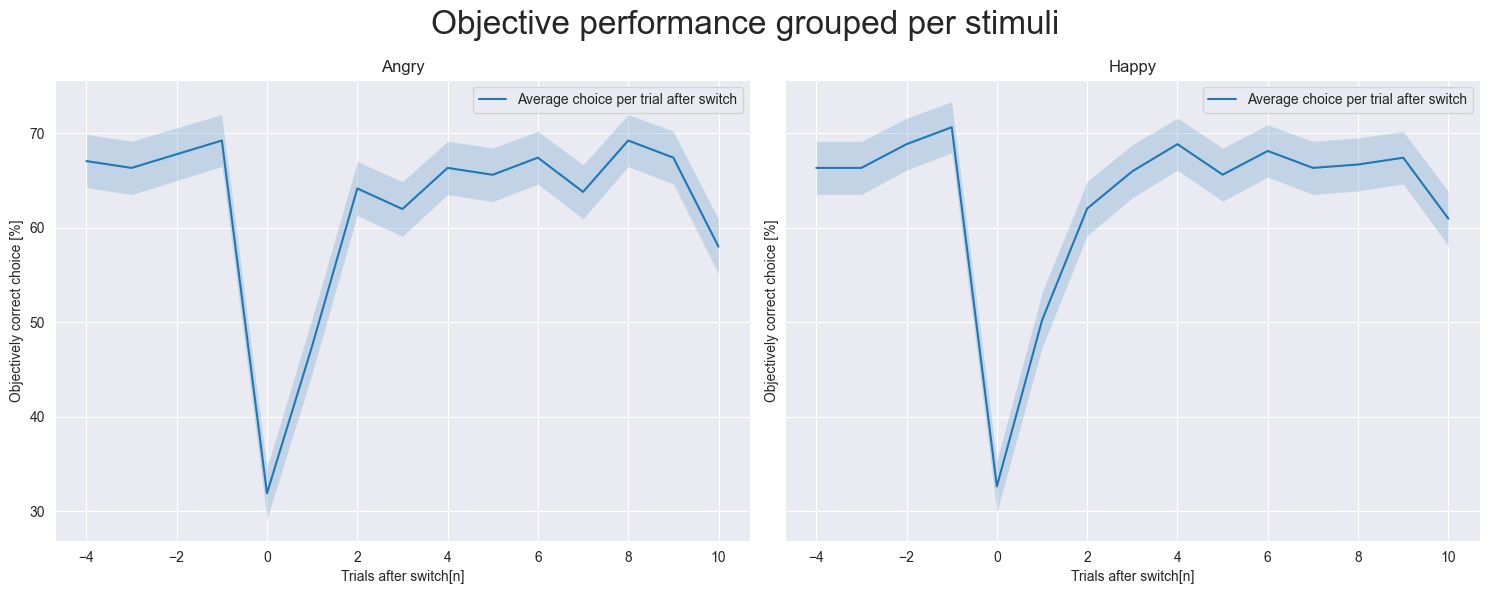

In [318]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped per stimuli', fontsize=24, y=0.982)

stimuli_types_list = ['Angry', 'Happy']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    #axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch[n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_per_stimuli_4-12.pdf'))
plt.show()

# Subplots for incongruent and congruent switches

In [319]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                 unique_subject_ids,
                                                                 unique_stimuli_types,
                                                                 'congruency',
                                                                 plot_range,
                                                                 mapping)
print(all_switches_dataframe)

    subject_id  stimuli_type   congruency    0    1    2    3    4    5    6  \
0      sub-901             1    congruent    0    0    0  100    0    0    0   
1      sub-901             1    congruent    0    0  100    0    0    0    0   
2      sub-901             1    congruent  100    0    0    0    0  100  100   
3      sub-901             1    congruent  100    0  100  100    0  100    0   
4      sub-901             1    congruent    0    0  100  100  100  100  100   
..         ...           ...          ...  ...  ...  ...  ...  ...  ...  ...   
550    sub-915             3  incongruent    0    0  100  100  100  100    0   
551    sub-915             3  incongruent  100  100  100  100  100  100  100   
552    sub-915             3  incongruent    0    0  100  100  100  100  100   
553    sub-915             3  incongruent    0  100  100  100  100  100  100   
554    sub-915             3  incongruent    0  100  100  100  100  100    0   

       7    8    9   10  
0      0    0

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

               0    1    2    3    4    5    6    7    8    9   10
congruency                                                        
congruent      0    0    0  100    0    0    0    0    0  100  100
congruent      0    0  100    0    0    0    0  100  100    0    0
congruent    100    0    0    0    0  100  100    0  100    0  100
congruent    100    0  100  100    0  100    0    0    0  100    0
congruent      0    0  100  100  100  100  100  100    0  100    0
...          ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...
incongruent    0    0  100  100  100  100    0    0  100  100  100
incongruent  100  100  100  100  100  100  100  100  100  100  100
incongruent    0    0  100  100  100  100  100    0  100  100  100
incongruent    0  100  100  100  100  100  100  100  100    0  100
incongruent    0  100  100  100  100  100    0  100    0  100  100

[555 rows x 11 columns]


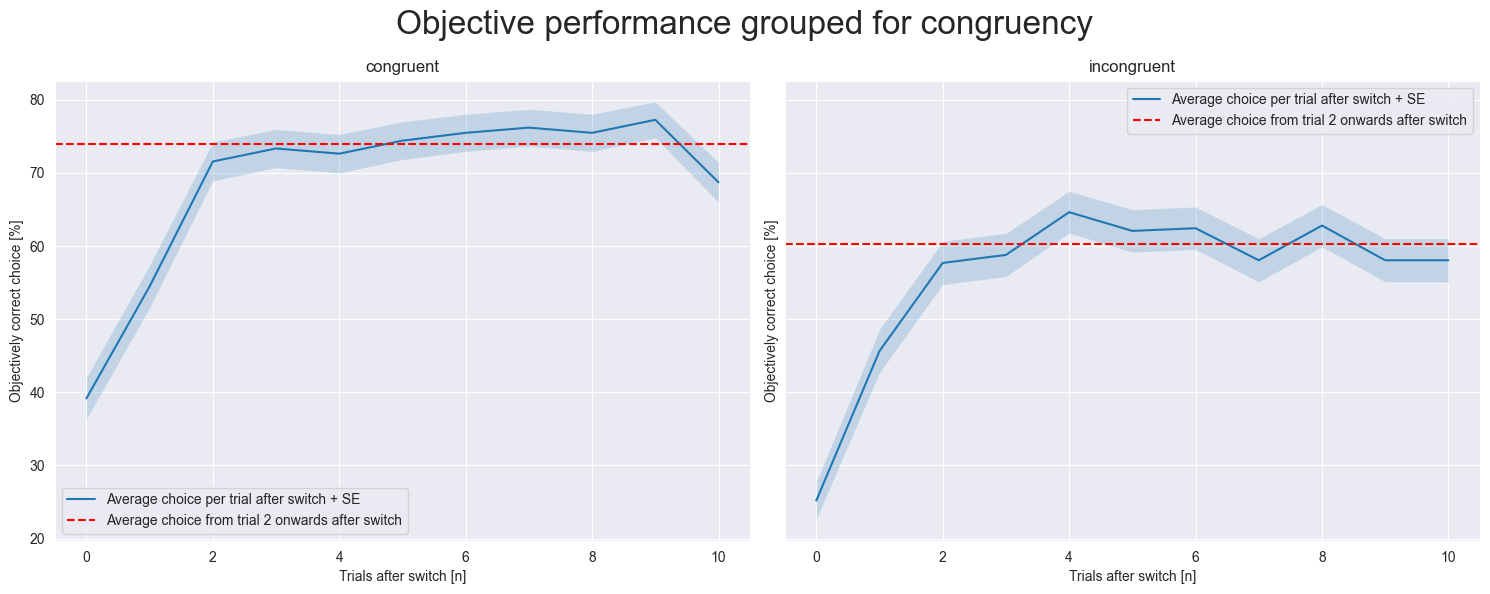

In [320]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()
print(df)

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_type)
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

# Subplots for reversal and non-reversal switches

In [321]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'all_reversals', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe_separate_reversals(combined_results_dataframe,
                                                                                          unique_subject_ids,
                                                                                          unique_stimuli_types,
                                                                                          plot_range,
                                                                                          mapping)
print(all_switches_dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:675: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:675: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_ana

    subject_id  stimuli_type  all_reversals    0    1    2    3    4    5  \
0      sub-901             1            1.0    0    0    0  100    0    0   
1      sub-901             1            1.0  100    0    0  100  100  100   
2      sub-901             1            1.0    0    0  100    0    0    0   
3      sub-901             1            1.0    0    0  100    0  100  100   
4      sub-901             1            1.0  100    0    0    0    0  100   
..         ...           ...            ...  ...  ...  ...  ...  ...  ...   
550    sub-915             3            1.0    0  100  100  100  100  100   
551    sub-915             3            1.0    0  100  100  100  100  100   
552    sub-915             3            1.0    0    0  100  100  100  100   
553    sub-915             3            1.0    0  100  100  100  100  100   
554    sub-915             3            1.0    0    0    0  100  100    0   

       6    7    8    9   10  
0      0    0    0  100  100  
1    100    0

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:675: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)


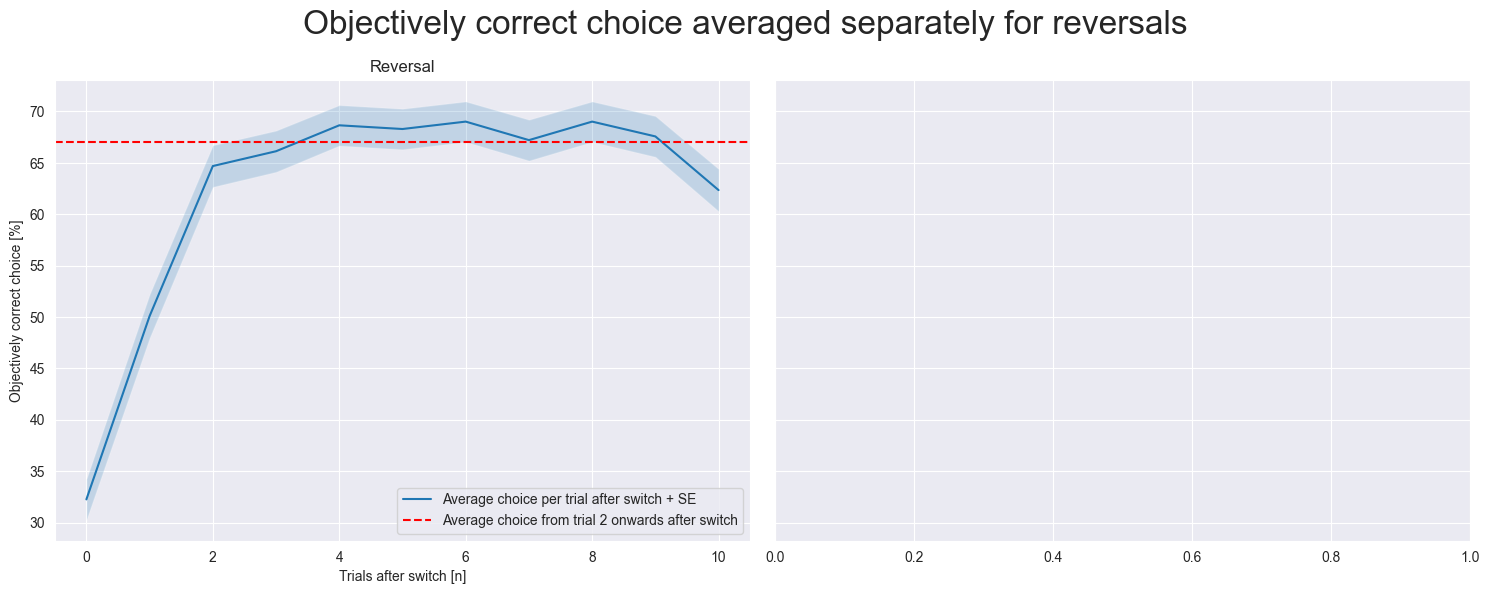

In [322]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('all_reversals')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('all_reversals').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('all_reversals').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False,
                        sharey=True)  # Adjust based on the number of stimuli_types
axs = axs.flatten()  # Flatten to iterate easily

fig.suptitle('Objectively correct choice averaged separately for reversals', fontsize=24, y=0.982)

reversal_list = ['Reversal','Non-reversal']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--',
                   label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(reversal_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
#plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_for_reversals.pdf'))
plt.show()

# Time before stabilisation
This will be the amount of trials before participants reach an average response of x%

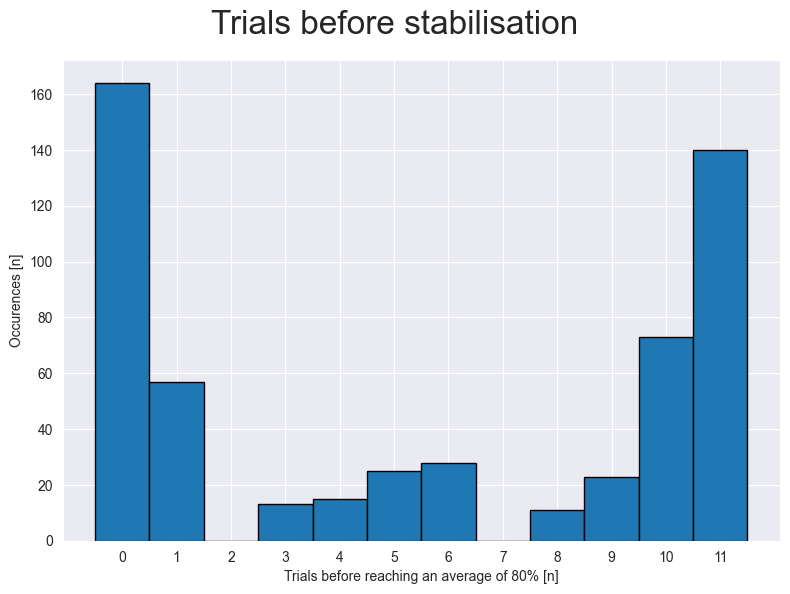

In [323]:
# Set some plotting guidelines
stable_performance = 80
bin_range = [0, 10]
sequence_bin_range = range(min(bin_range), max(bin_range) + 3)
sequence_tick_range = range(min(bin_range), max(bin_range) + 2)

# Create subplots
fig, axes = plt.subplots(figsize=(8, 6), sharey=True)

fig.suptitle('Trials before stabilisation', fontsize=24, y=0.982)

# Bin edges centered around the ticks
bin_edges = [i - 0.5 for i in sequence_bin_range]

# Plot for switch value 1.0
reversal_results = utils.analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, bin_range, 1.0)
axes.hist(reversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
#axes.set_title(reversal_list[0])
axes.set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes.set_ylabel('Occurences [n]')
axes.set_xticks(sequence_tick_range)

ticks = axes.get_xticks()
tick_labels = axes.get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes.set_xticklabels(tick_labels)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_trials_before_stabilisation.pdf'))
plt.show()

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [324]:
# First create a new dataframe with the 
bin_range = [-6, 6]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, bin_range) 

#print(dataframe)

[0, 26, 57, 65, 77, 87, 99, 130, 158, 170, 180, 194, 206, 237, 265, 279, 289, 301, 315, 326, 351, 382, 392, 403, 413, 425, 457, 485, 498, 508, 522, 534, 566, 594, 607, 617, 629, 643, 665, 677, 687, 699, 731, 759, 773, 783, 797, 809, 841, 869, 883, 893, 905, 919, 951, 979, 991, 1001, 1012, 1022, 1034, 1092, 1106, 1116, 1130, 1142, 1173, 1201, 1215, 1225, 1237, 1251, 1283, 1311, 1335, 1344, 1365, 1390, 1433, 1447, 1457, 1468, 1496, 1527, 1540, 1550, 1562, 1576, 1603, 1635, 1647, 1667, 1676, 1686, 1711, 1743, 1754, 1767, 1777, 1789, 1817, 1849, 1863, 1873, 1885, 1899, 1926, 1958, 1999, 2023, 2034, 2044, 2055, 2064, 2089, 2117, 2125, 2135, 2149, 2161, 2187, 2218, 2232, 2242, 2253, 2267, 2278, 2305, 2332, 2345, 2355, 2366, 2378, 2437, 2447, 2456, 2470, 2481, 2509, 2540, 2553, 2563, 2575, 2589, 2601, 2629, 2661, 2671, 2691, 2703, 2735, 2762, 2776, 2786, 2799, 2810, 2842, 2883, 2892, 2903, 2916, 2928, 2956, 2987, 2997, 3009, 3018, 3030, 3061, 3089, 3103, 3113, 3127, 3139, 3169, 3210, 3219, 32

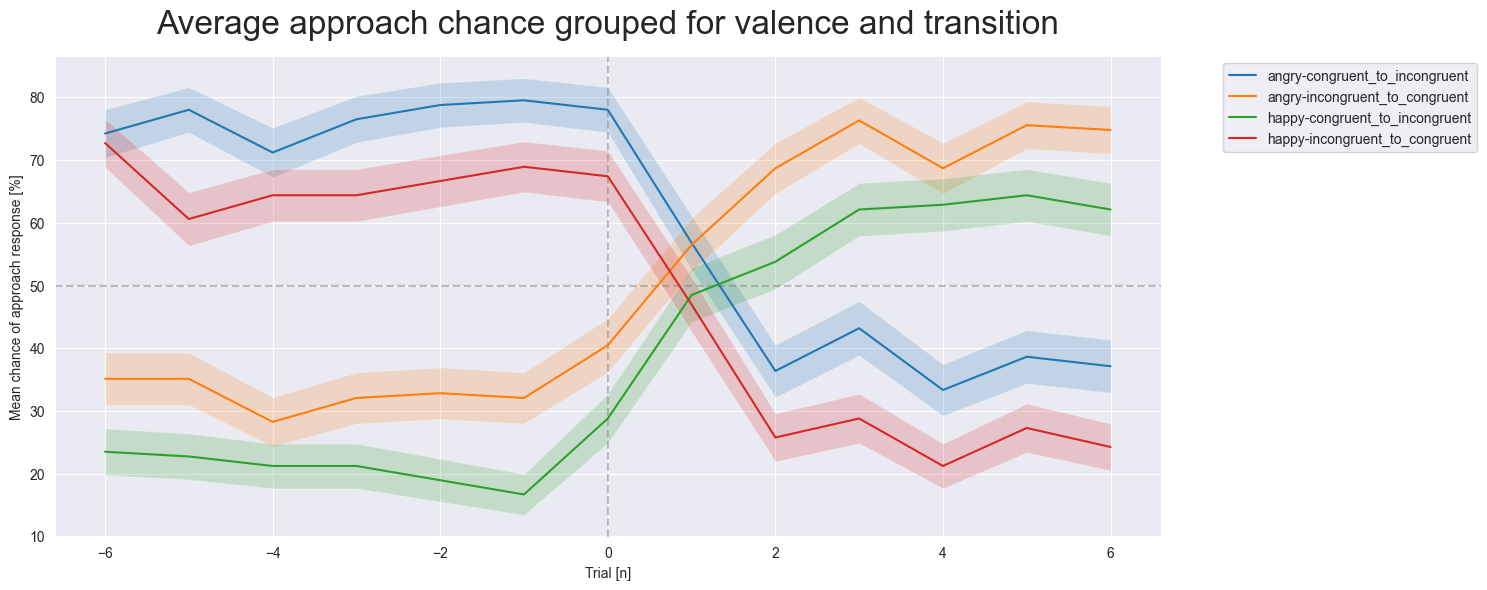

In [325]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

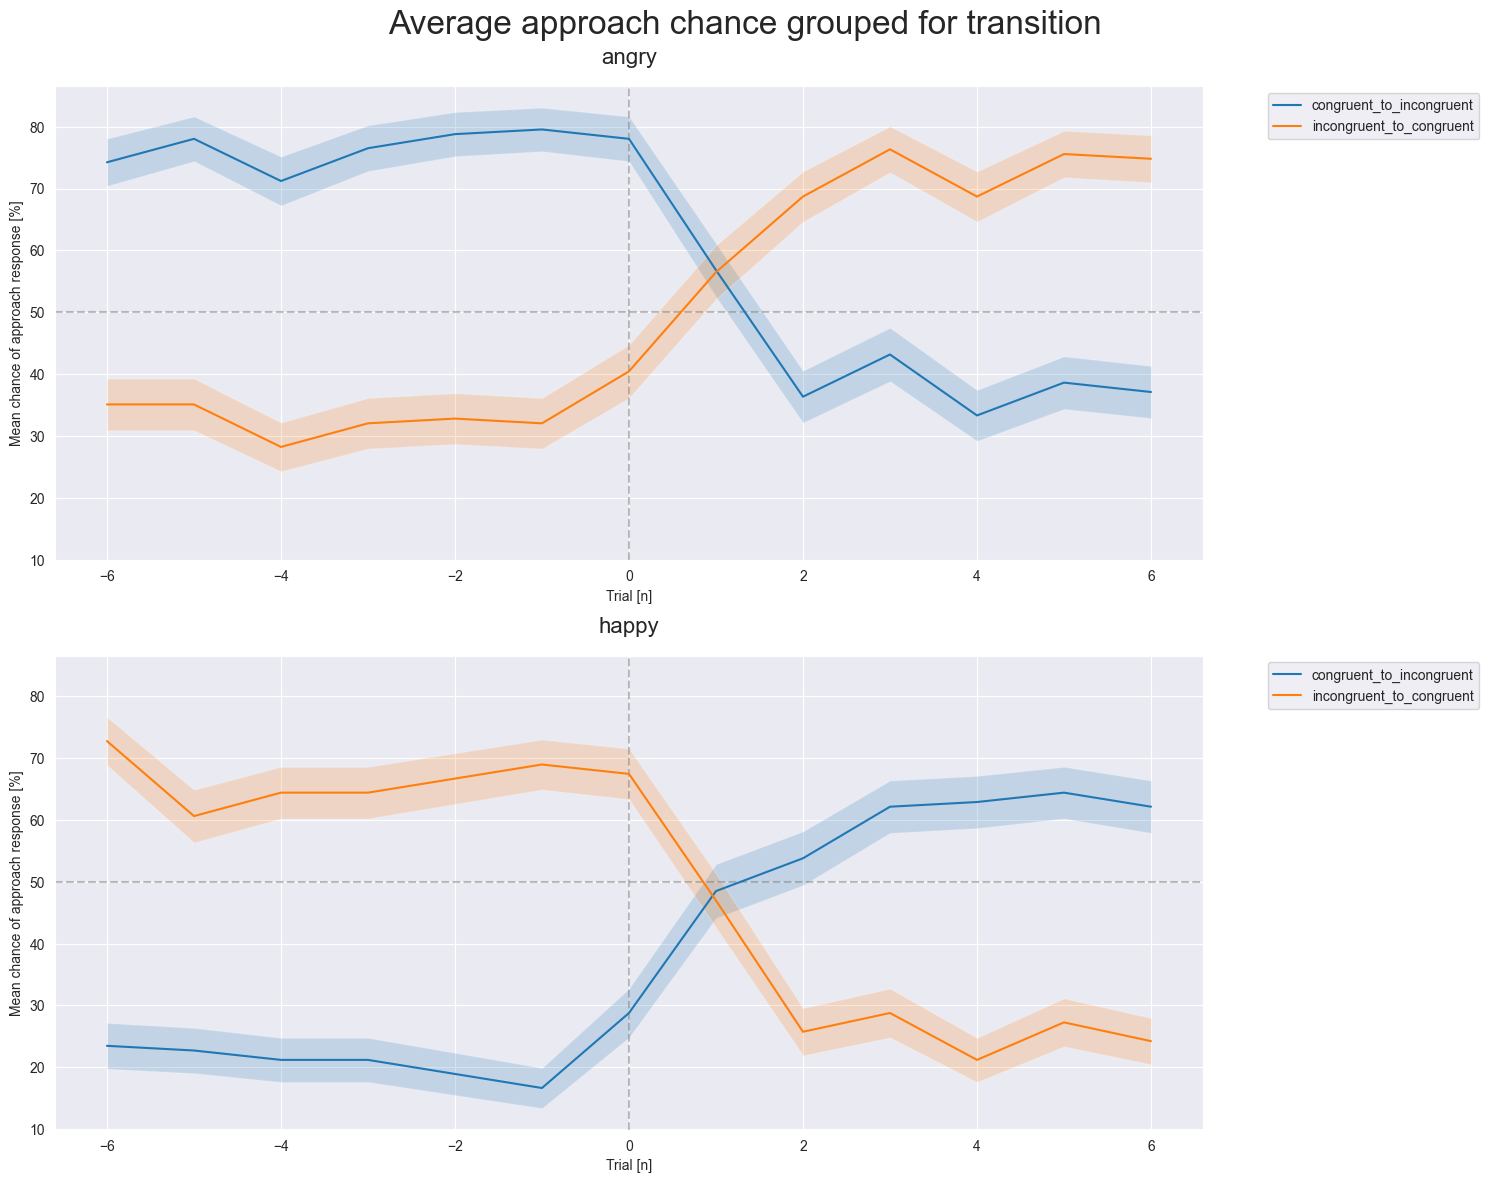

In [326]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Plot volatile and stable blocks separately

In [327]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids,
                                                                unique_stimuli_types,
                                                                'volatility',
                                                                plot_range,
                                                                mapping)

print(dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

    stimuli_type  subject_id volatility    0    1    2    3    4    5    6  \
0        sub-901           1     stable    0    0    0  100    0    0    0   
1        sub-901           1     stable  100    0    0  100  100  100  100   
2        sub-901           1     stable    0    0  100    0    0    0    0   
3        sub-901           1     stable  100    0  100    0  100  100  100   
4        sub-901           1     stable    0    0  100  100  100  100  100   
..           ...         ...        ...  ...  ...  ...  ...  ...  ...  ...   
550      sub-915           3     stable    0    0    0    0    0    0  100   
551      sub-915           3     stable    0  100  100  100  100  100  100   
552      sub-915           3     stable    0    0  100  100  100  100    0   
553      sub-915           3     stable    0    0  100  100  100  100  100   
554      sub-915           3     stable    0  100  100  100  100  100  100   

       7    8    9   10  
0      0    0  100  100  
1      0   

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:621: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

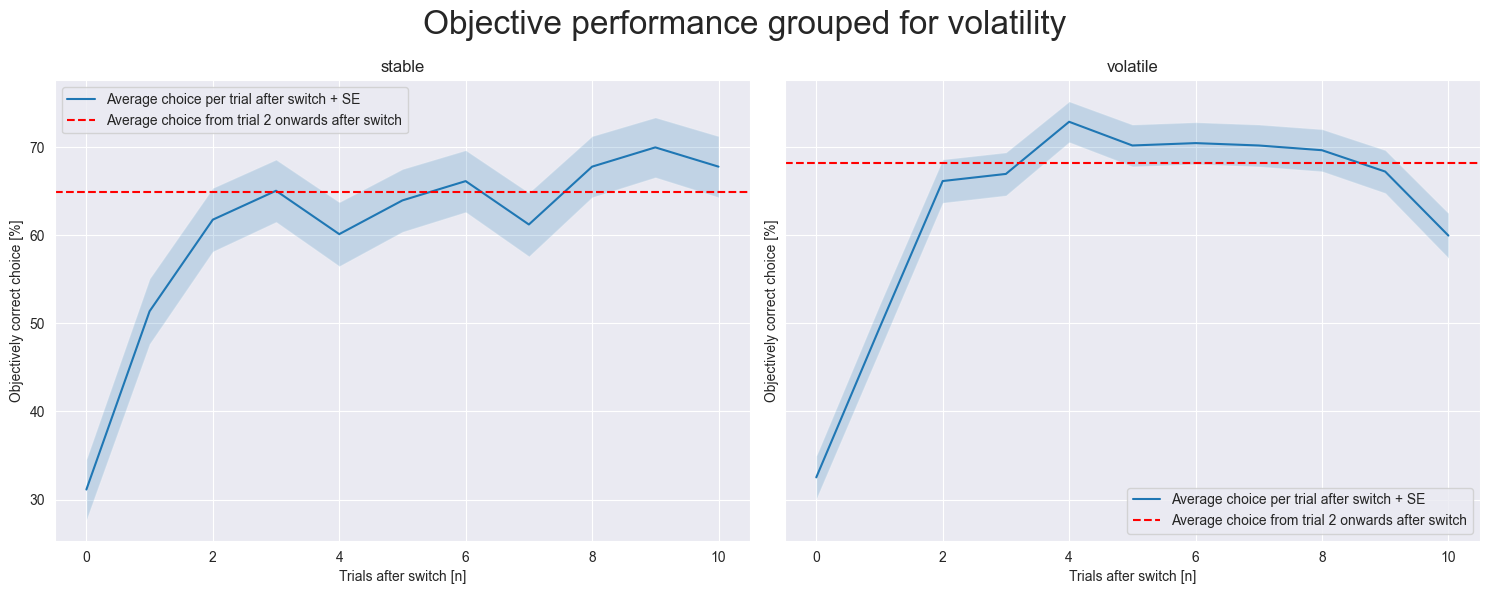

In [328]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe.set_index('volatility')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

# Now do the same thing but split them for congruency

In [329]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6, 11:7, 12:8, 13: 9, 14: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids,
                                                                unique_stimuli_types,
                                                                'volatility',
                                                                plot_range,
                                                                mapping,
                                                                True)

print(dataframe)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:578: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

     subject_id  stimuli_type   congruency volatility    0    1    2    3  \
0       sub-901             1    congruent     stable    0    0    0  100   
1       sub-901             1    congruent     stable  100    0    0  100   
2       sub-901             1    congruent     stable    0    0  100    0   
3       sub-901             1    congruent     stable  100    0    0    0   
4       sub-901             1    congruent     stable  100    0  100  100   
...         ...           ...          ...        ...  ...  ...  ...  ...   
1660    sub-915             3  incongruent     stable  100  100  100  100   
1661    sub-915             3  incongruent     stable    0    0  100  100   
1662    sub-915             3  incongruent     stable    0  100  100  100   
1663    sub-915             3  incongruent     stable    0  100  100  100   
1664    sub-915             3  incongruent     stable    0  100  100  100   

        4    5    6    7    8    9   10  
0       0    0    0    0    0  10

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:578: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:578: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/

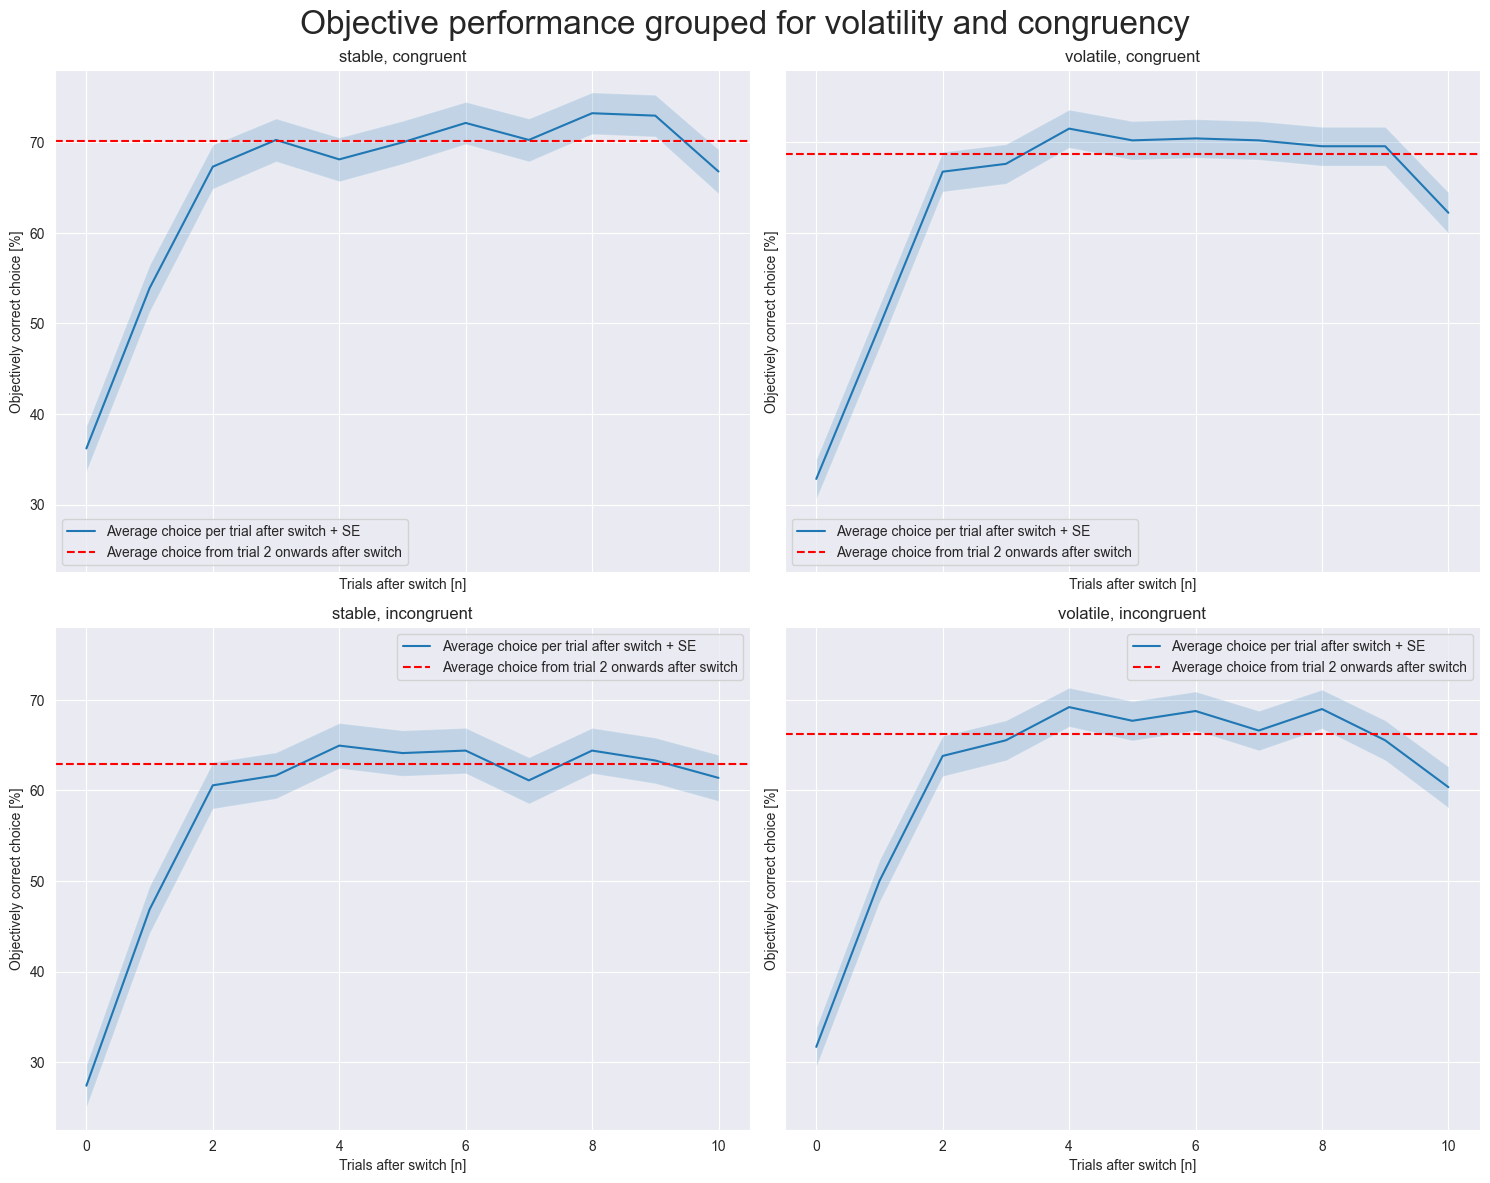

In [330]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

In [331]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a switch
bin_range = [-6, 6]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, bin_range, 'volatility')

#print(dataframe)
[0, 29, 59, 66, 74, 80, 87, 94, 100, 130, 158, 166, 171, 178, 186, 193, 199, 228, 255, 261, 267, 281, 287, 295, 301, 333, 363, 370, 378, 384, 390, 397, 404, 435, 463, 471, 477, 485, 493, 500, 506, 536, 564, 570, 576, 583, 591, 597, 605, 641, 668, 673, 681, 688, 709, 737, 765, 772, 778, 784, 798, 803, 834, 866, 873, 879, 884, 889, 897, 903, 909, 939, 967, 973, 981, 988, 996, 1003, 1011, 1039, 1068, 1075, 1082, 1087, 1094, 1100, 1105, 1137, 1166, 1173, 1180, 1186, 1192, 1199, 1205]

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:236: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


[0, 26, 57, 65, 77, 87, 99, 130, 158, 170, 180, 194, 206, 237, 265, 279, 289, 301, 315, 326, 351, 382, 392, 403, 413, 425, 457, 485, 498, 508, 522, 534, 566, 594, 607, 617, 629, 643, 665, 677, 687, 699, 731, 759, 773, 783, 797, 809, 841, 869, 883, 893, 905, 919, 951, 979, 991, 1001, 1012, 1022, 1034, 1092, 1106, 1116, 1130, 1142, 1173, 1201, 1215, 1225, 1237, 1251, 1283, 1311, 1335, 1344, 1365, 1390, 1433, 1447, 1457, 1468, 1496, 1527, 1540, 1550, 1562, 1576, 1603, 1635, 1647, 1667, 1676, 1686, 1711, 1743, 1754, 1767, 1777, 1789, 1817, 1849, 1863, 1873, 1885, 1899, 1926, 1958, 1999, 2023, 2034, 2044, 2055, 2064, 2089, 2117, 2125, 2135, 2149, 2161, 2187, 2218, 2232, 2242, 2253, 2267, 2278, 2304, 2331, 2344, 2354, 2365, 2377, 2436, 2446, 2455, 2469, 2480, 2508, 2539, 2552, 2562, 2574, 2588, 2600, 2628, 2660, 2670, 2690, 2702, 2734, 2761, 2775, 2785, 2798, 2809, 2841, 2882, 2891, 2902, 2915, 2927, 2955, 2986, 2996, 3008, 3017, 3029, 3060, 3088, 3102, 3112, 3126, 3138, 3168, 3209, 3218, 32

[0,
 29,
 59,
 66,
 74,
 80,
 87,
 94,
 100,
 130,
 158,
 166,
 171,
 178,
 186,
 193,
 199,
 228,
 255,
 261,
 267,
 281,
 287,
 295,
 301,
 333,
 363,
 370,
 378,
 384,
 390,
 397,
 404,
 435,
 463,
 471,
 477,
 485,
 493,
 500,
 506,
 536,
 564,
 570,
 576,
 583,
 591,
 597,
 605,
 641,
 668,
 673,
 681,
 688,
 709,
 737,
 765,
 772,
 778,
 784,
 798,
 803,
 834,
 866,
 873,
 879,
 884,
 889,
 897,
 903,
 909,
 939,
 967,
 973,
 981,
 988,
 996,
 1003,
 1011,
 1039,
 1068,
 1075,
 1082,
 1087,
 1094,
 1100,
 1105,
 1137,
 1166,
 1173,
 1180,
 1186,
 1192,
 1199,
 1205]

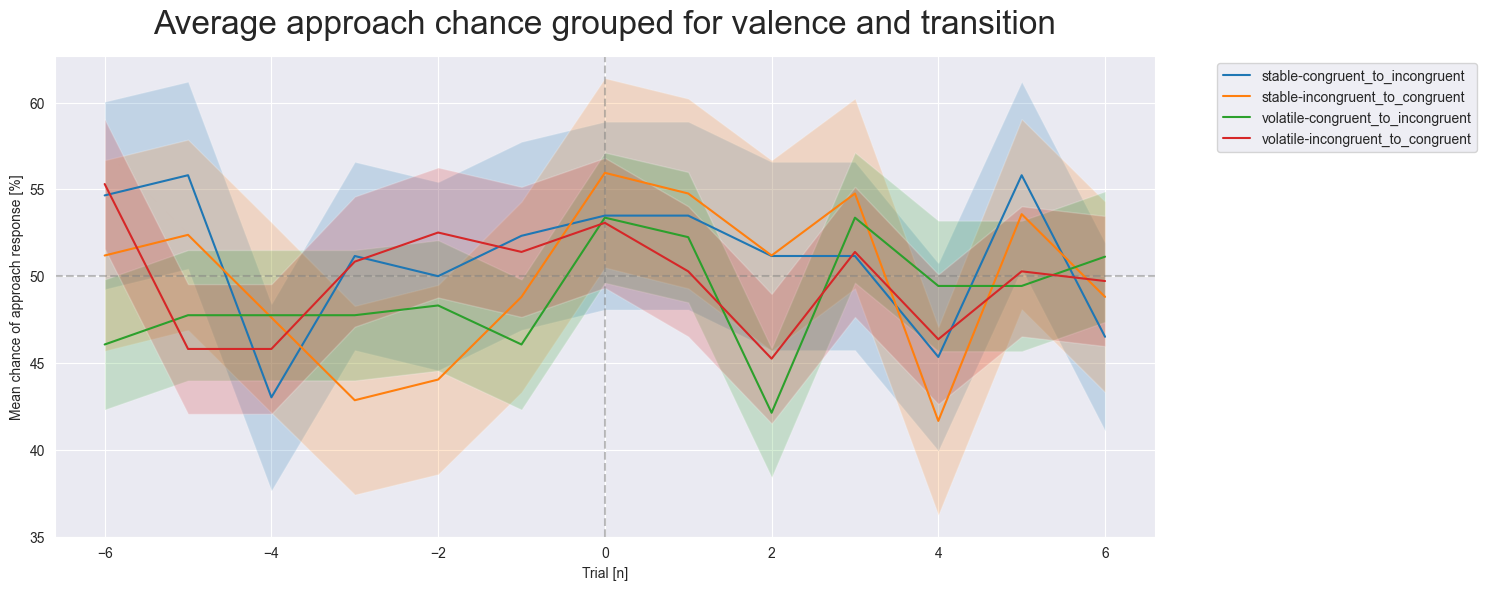

In [332]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'volatility', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

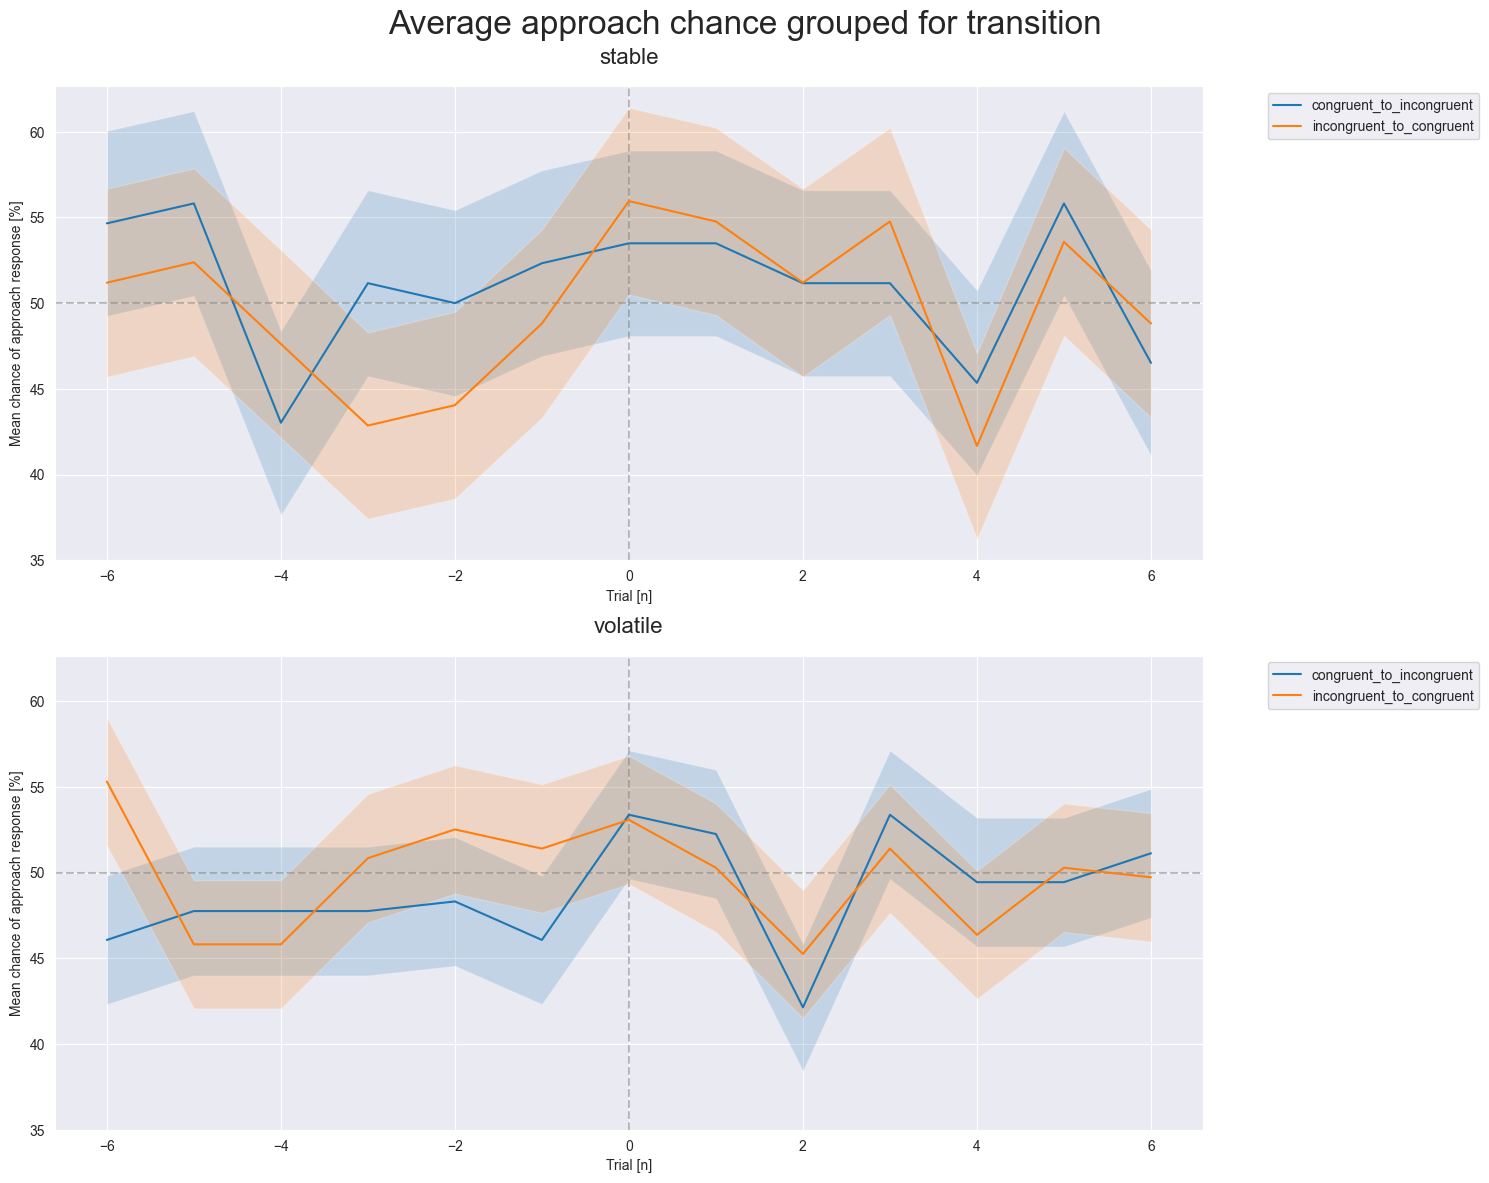

In [333]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()